In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image

In [13]:
class BMI(TypedDict):
    weight: float
    height: float
    bmi: float
    category: str

In [14]:
def calculate_bmi(data: BMI) -> float:
    weight = data["weight"]
    height = data["height"]

    bmi = weight / (height ** 2)
    data["bmi"] = round(bmi, 2)
    return data

In [15]:
def label_bmi(data: BMI) -> str:
    bmi = data["bmi"]
    if bmi < 18.5:
        data["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        data["category"] = "Normal weight"
    elif 25 <= bmi < 30:
        data["category"] = "Overweight"
    else:
        data["category"] = "Obesity"
    
    return data

In [16]:
graph = StateGraph(BMI)

graph.add_node("Calculate BMI", calculate_bmi)
graph.add_node("Label BMI", label_bmi)
graph.add_edge(START, "Calculate BMI")
graph.add_edge("Calculate BMI", "Label BMI")
graph.add_edge("Label BMI", END)

workflow = graph.compile()

In [17]:
initial_data = {"weight": 70, "height": 1.75}
output = workflow.invoke(initial_data)
print(output)

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}


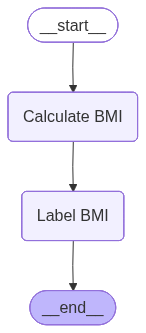

In [19]:
Image(workflow.get_graph().draw_mermaid_png())